# Credit Card Fraud Detection — Analisi Esplorativa

**Notebook 1 di 3** · Exploratory Data Analysis e valutazione della qualità del dato

Dataset: [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) - 284.807 transazioni con carta di credito, di cui 492 fraudolente.

---

### Obiettivo

Prima di costruire qualsiasi modello, capire con che dati si ha a che fare: struttura, completezza, validità, anomalie. E verificare quali variabili portano davvero segnale.

L'analisi segue l'ordine con cui si affronta una fonte dati sconosciuta: prima la struttura, poi la qualità, poi il contenuto.

## 1. Setup e caricamento

In [50]:
# Librerie per manipolazione dati e analisi
import pandas as pd
import numpy as np

# Librerie per la visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione display: mostra tutte le colonne del dataset
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Silenzia i warning non critici per mantenere l'output leggibile
import warnings
warnings.filterwarnings('ignore')

print("Librerie caricate correttamente")

Librerie caricate correttamente


In [51]:
# Caricamento del dataset
df = pd.read_csv('creditcard.csv')

# Dimensioni: quante osservazioni e quante variabili abbiamo
print(f"Righe: {df.shape[0]:,}")
print(f"Colonne: {df.shape[1]}")
# deep=True calcola la memoria reale del contenuto, non solo dei riferimenti:
# su colonne testuali la differenza è sostanziale e senza questo parametro si sottostima
print(f"Memoria occupata: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

# Prima occhiata al contenuto reale
df.head()

Righe: 284,807
Colonne: 31
Memoria occupata: 67.4 MB



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Struttura del dataset

Primo controllo di profiling: tipo di ogni colonna e conteggio dei valori non nulli.

Una colonna numerica letta come 'object' segnalerebbe valori sporchi - testo, separatori decimali errati, placeholder.

In [52]:
# Struttura del dataset: tipo di ogni colonna e conteggio dei valori non nulli
# In fase di profiling questo è il primo controllo: una colonna numerica letta
# come 'object' segnala valori sporchi (testo, separatori decimali errati, placeholder)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Le colonne sono tutte numeriche e nessuna presenta valori nulli.

`Time` è dichiarata come `float64` ma contiene valori interi (secondi trascorsi dalla prima transazione): incoerenza di tipizzazione che non compromette l'analisi ma vale la pena annotare.

Le variabili **V1–V28** sono il risultato di una trasformazione PCA applicata da chi ha generato il dataset per motivi di riservatezza bancaria: il significato originale di ciascun campo non lo conosciamo. Restano in chiaro solo `Time`, `Amount` e `Class`.

## 3. Completezza

**La verifica dei NaN non basta: un campo può essere popolato ma non valido.**

I *missing mascherati*,  zeri, placeholder, valori sentinella - sono il caso più insidioso perchè superano qualsiasi controllo di completezza formale.

In [53]:
print("COMPLETEZZA FORMALE")
print(f"Valori nulli totali: {df.isnull().sum().sum()}")
print()

print("COMPLETEZZA SOSTANZIALE")
# Amount a zero: una transazione di importo nullo non è un evento economico reale
amount_zero = (df['Amount'] == 0).sum()
print(f"Transazioni con Amount uguale a 0 sono: {amount_zero:,} ({amount_zero/len(df)*100:.2f}%)")

# Verifichiamo se il fenomeno è distribuito o si concentra su una classe
print()
print("Distribuzione degli Amount = 0 per classe:")
print(df[df['Amount'] == 0]['Class'].value_counts())

# il tasso di frode tra gli Amount = 0 rispetto al dataset
zero = df[df['Amount'] == 0]
print()
print(f"Tasso di frode tra gli Amount = 0: {zero['Class'].mean()*100:.2f}%")
print(f"Tasso di frode sul dataset:        {df['Class'].mean()*100:.2f}%")

COMPLETEZZA FORMALE
Valori nulli totali: 0

COMPLETEZZA SOSTANZIALE
Transazioni con Amount uguale a 0 sono: 1,825 (0.64%)

Distribuzione degli Amount = 0 per classe:
0    1798
1      27
Name: Class, dtype: int64

Tasso di frode tra gli Amount = 0: 1.48%
Tasso di frode sul dataset:        0.17%


**Tra le transazioni con importo a zero il tasso di frode è dell'1,48% contro lo 0,17% del dataset: circa nove volte più alto.**

A questo punto delle analisi non abbiamo abbastanza approfondito per spiegare l'anomalia, ma possiamo avanzare, conoscendo il funzionamento dei circuiti di pagamento, una prima ipotesi: un'autorizzazione a importo zero verifica che una carta sia attiva senza addebitare nulla, ed è lo strumento tipico del *card testing*, la verifica preliminare di una carta rubata prima di utilizzarla davvero. L'altra ipotesi, invece, è che ci siano righe tecniche finite nel dataset per errore.

Nel primo caso è segnale e va tenuto, nel secondo è rumore.

**Si è scelto di mantenerli e di verificare più avanti se il comportamento trova riscontro in altri elementi**
in particolare nella distribuzione degli importi più frequenti tra le frodi (sezione 8)

## 4. Distribuzione della variabile target

Quantifichiamo lo sbilanciamento, che è la caratteristica dominante del problema e condiziona ogni scelta successiva.

In [54]:
frodi = df['Class'].sum()
totale = len(df)
print(f"Frodi: {frodi:,} su {totale:,}")
print(f"Tasso di frode: {frodi/totale*100:.2f}%")
print(f"Rapporto normali/frodi: 1 a {round((totale-frodi)/frodi)}")
print()
print(f"Accuracy di un modello che risponde sempre 'non frode': {(1 - df['Class'].mean())*100:.2f}%")

Frodi: 492 su 284,807
Tasso di frode: 0.17%
Rapporto normali/frodi: 1 a 578

Accuracy di un modello che risponde sempre 'non frode': 99.83%


**Il dataset è sbilanciato: circa una frode ogni 578 transazioni, lo 0,17%.**

Con questa proporzione l'accuracy è inutile come metrica, un modello che rispondesse sempre 'non è frode' otterrebbe il 99,83%. L'attenzione va su Recall e AUC-ROC.

## 5. Duplicati

**I duplicati esatti sono critici in ambito ML: se la stessa riga finisce in training e in test, il modello riconosce un record già visto e le performance risultano artificialmente gonfiate.**

Con una classe minoritaria di sole 492 righe, i duplicati sulle frodi hanno un peso proporzionalmente molto maggiore.

In [55]:
duplicati = df.duplicated().sum()
print(f"Righe duplicate esatte: {duplicati:,} ({duplicati/len(df)*100:.2f}%)")
print()

print("Distribuzione dei duplicati per classe:")
print(df[df.duplicated()]['Class'].value_counts())

Righe duplicate esatte: 1,081 (0.38%)

Distribuzione dei duplicati per classe:
0    1062
1      19
Name: Class, dtype: int64


I numeri assoluti ingannano: 1.062 duplicati sulle normali contro 19 sulle frodi. Ma i due gruppi hanno dimensioni molto diverse, quindi vanno rapportati alla propria base.

| Classe | Duplicati | Totale | Tasso |
|---|---|---|---|
| Normali | 1.062 | 284.315 | 0,37% |
| Frodi | 19 | 492 | 3,9% |

**Le frodi sono duplicate dieci volte più spesso delle transazioni normali: il problema si concentra proprio dove il dataset è più fragile.**

Ci sono 492 frodi in tutto e 19 di queste sono copie. Se finiscono a cavallo tra training e test, il modello ripesca in test frodi che ha già memorizzato, e il Recall misurato risulta più alto di quello reale.

### Decisione operativa

**I duplicati esatti vanno rimossi:** due righe identiche in ogni campo, incluso `Time` che è un contatore in secondi, non sono due transazioni distinte ma un artefatto. 

Non li rimuoviamo però dal dataset originario: manteniamo la versione originale accanto a quella pulita, per poter misurare più avanti l'impatto della pulizia sulle performance del modello.

In [56]:
df_pulito = df.drop_duplicates().copy()

print(f"Dataset originale: {len(df):,} righe")
print(f"Dataset pulito:    {len(df_pulito):,} righe")
print(f"Rimosse:           {len(df) - len(df_pulito):,} righe")
print()
print("Frodi prima:  ", df['Class'].sum())
print("Frodi dopo:   ", df_pulito['Class'].sum())

Dataset originale: 284,807 righe
Dataset pulito:    283,726 righe
Rimosse:           1,081 righe

Frodi prima:   492
Frodi dopo:    473


La pulizia rimuove il 3,8% delle frodi contro lo 0,37% delle transazioni normali: **incide dieci volte di più sulla classe rara**, che è precisamente il motivo per cui quei duplicati erano pericolosi.

> **Da questo punto l'analisi prosegue su `df_pulito`.**
>
> Analizzare dati che poi verrebbero scartati sarebbe incoerente: l'esplorazione va fatta
> sul dataset su cui verrà costruito il modello. La versione originale `df` resta
> disponibile per il confronto sull'impatto della qualità del dato, previsto nel
> notebook successivo.

## 6. La variabile `Amount`

### 6.1 Validità e dominio

**I valori rientrano in ciò che il campo dovrebbe contenere?**

`Amount` dovrebbe essere l'importo dell'operazione, quindi un valore assoluto sempre positivo. Un negativo potrebbe significare un rimborso registrato male, un errore di segno, o una convenzione diversa da quella assunta.

Un controllo che esce a zero non è tempo perso: è la conferma che il campo significa quello che si presume.

In [76]:
print(f"Importi negativi:  {(df_pulito['Amount'] < 0).sum()}")
print(f"Importi a zero:    {(df_pulito['Amount'] == 0).sum():,}")
print(f"Valori non numerici: {df_pulito['Amount'].isnull().sum()}")

Importi negativi:  0
Importi a zero:    1,808
Valori non numerici: 0


Dominio di Amount regge, nessuna sorpresa

### 6.2 Range e concentrazione

Dove arrivano i valori e dove si concentra la massa dei dati.

In [77]:
# Arrotondo a due decimali perché sono euro: sei cifre dopo la virgola non servono
df_pulito['Amount'].describe().round(2)

count    283726.00
mean         88.47
std         250.40
min           0.00
25%           5.60
50%          22.00
75%          77.51
max       25691.16
Name: Amount, dtype: float64

Il punto da osservare è quello sulla deviazione standard 250 con una media di 88, quindi, la dispersione è
quasi 3 volte il valore medio, questo vuol dire che qualcosa tira da una parte. 

Inoltre il valore della mediana 22 contro gli 88 della media, 4 volte più alta
con un massimo di 25691 che è circa 1000 volte la mediana. 

Questo ci fa pensare che se media e mediana divergono così tanto ci sono pochi valori molto alti che stanno trascinando 
la media più su, c'è una coda lunga a destra?

Al terzo quartile osserviamo valori fermi a 77 euro fino al valore massimo 25691
tra i due c'è un intervallo molto ampio di cui non sappiamo nulla.
Guardiamo i percentili alti per capire se il passaggio è graduale

### 6.3 I percentili alti

`describe()` si ferma al 75° percentile, a 77 euro. Tra lì e il massimo a 25.691 c'è un intervallo molto ampio di cui non si sa nulla: **il passaggio è graduale o c'è un salto concentrato negli ultimi valori?**

In [78]:
percentili = df_pulito['Amount'].quantile([0.75, 0.90, 0.95, 0.99, 0.999])
percentili.index = [f"{q*100:g}° percentile" for q in percentili.index]
print(percentili.to_string(float_format='{:,.2f}'.format))
print(f"\nmassimo: {df_pulito['Amount'].max():,.2f}")

75° percentile        77.51
90° percentile       203.38
95° percentile       365.34
99° percentile     1,018.97
99.9° percentile   3,004.75

massimo: 25,691.16


Noto che ci sono due salti negli ultimi percentili, dal 95 percentile al 99 e
dal 99 al 99,9 percentile. Ma il salto più grande è tra il 99,9 percentile e
il massimo: un intervallo molto ampio concentrato nello 0.1%. 
questa coda da quante transazioni è costituita?
pochi valori staccati farebbero sospettare un errore di caricamento del dato (esempio virgola al posto sbagliato, valore sentinella)
mentre una coda continua descriverebbe un fenomeno reale di operazioni con importo elevato.
Verifico contando le transazioni sopra i 3004.75.

### 6.4 La coda è reale o è un errore?

In [80]:
soglia = 3000
sopra = df_pulito[df_pulito['Amount'] > soglia]

print(f"Transazioni sopra {soglia:,} euro: {len(sopra):,}")
print(f"Percentuale sul totale: {len(sopra)/len(df_pulito)*100:.3f}%")
print()
print("I dieci importi piu' alti:")
print(df_pulito['Amount'].nlargest(10).to_string(float_format='{:,.2f}'.format))

Transazioni sopra 3,000 euro: 284
Percentuale sul totale: 0.100%

I dieci importi piu' alti:
274771   25,691.16
58465    19,656.53
151296   18,910.00
46841    12,910.93
54018    11,898.09
169457   11,789.84
284249   10,199.44
227921   10,000.00
74699     8,790.26
245474    8,787.00


I dieci valori più alti scendono con continuità, pertanto la coda è reale e popolata: 
284 transazioni sopra i 3000 euro, lo 0,1% del totale.
Sono operazioni elevate ma plausibili.


### 6.5 La forma della distribuzione

Finora la distribuzione è stata descritta con dei numeri. **Il grafico serve a vederne la forma:** i percentili dicono dove stanno i valori, non come sono distribuiti nell'intervallo.

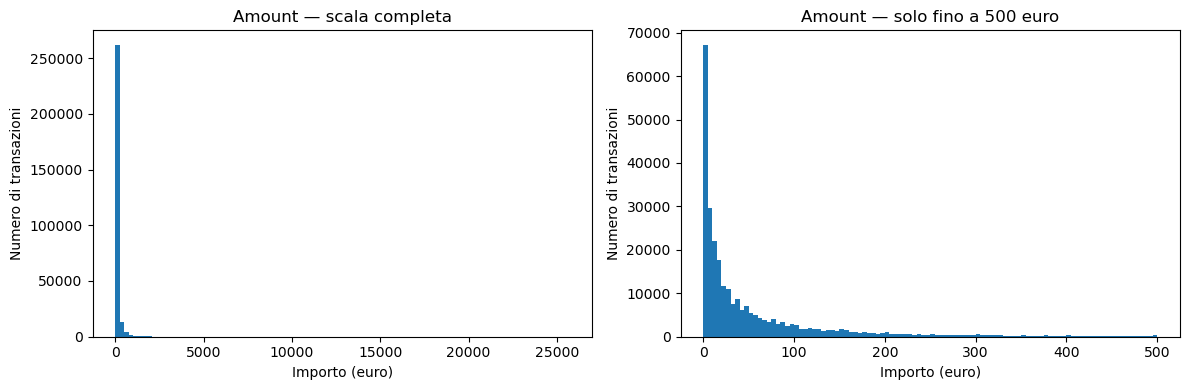

In [81]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_pulito['Amount'], bins=100)
plt.title('Amount — scala completa')
plt.xlabel('Importo (euro)')
plt.ylabel('Numero di transazioni')

plt.subplot(1, 2, 2)
plt.hist(df_pulito[df_pulito['Amount'] <= 500]['Amount'], bins=100)
plt.title('Amount — solo fino a 500 euro')
plt.xlabel('Importo (euro)')
plt.ylabel('Numero di transazioni')

plt.tight_layout()
plt.show()

Nel grafico a scala completa la massa è tutta schiacciata contro l'asse sinistro e il resto sembra vuoto: **il grafico 'vuoto' è esso stesso il risultato** - le transazioni oltre i mille euro sono così poche da risultare invisibili accanto alle 260.000 concentrate all'inizio.

Lo zoom sotto i 500 euro mostra la forma vera: picco altissimo nei primi euro e discesa continua. È una distribuzione fortemente asimmetrica a destra.

## 7. `Amount` distingue le frodi?

**La domanda che conta: le frodi si distinguono per importo?**

Se sì, `Amount` è una variabile utile al modello. Se le due distribuzioni si somigliano, porta poco segnale.

Nell'istogramma si usa `density=True` perché con 284.000 transazioni normali contro 492 frodi, senza normalizzare la seconda serie sarebbe invisibile: normalizzando, si confronta *come* si distribuiscono invece di *quante* sono.

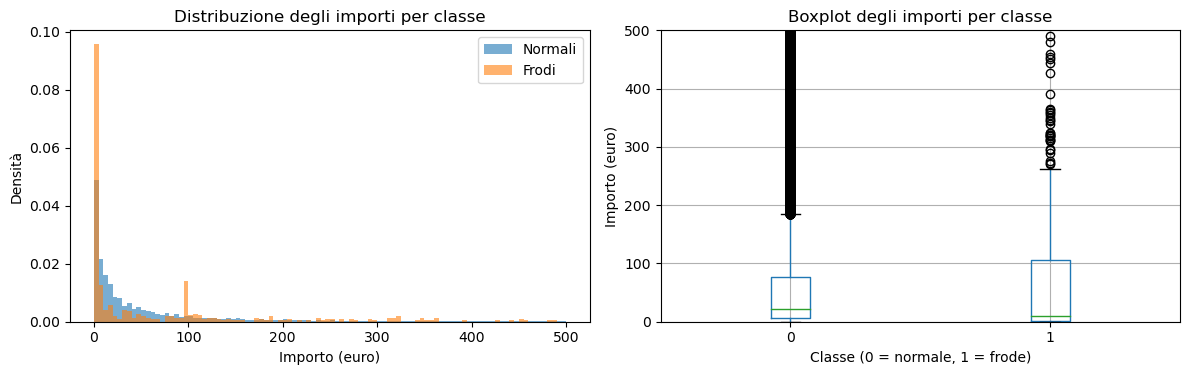

In [82]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_pulito[df_pulito['Class']==0]['Amount'], bins=100, range=(0, 500), alpha=0.6, label='Normali', density=True)
plt.hist(df_pulito[df_pulito['Class']==1]['Amount'], bins=100, range=(0, 500), alpha=0.6, label='Frodi', density=True)
plt.title('Distribuzione degli importi per classe')
plt.xlabel('Importo (euro)')
plt.ylabel('Densità')
plt.legend()

plt.subplot(1, 2, 2)
df_pulito.boxplot(column='Amount', by='Class', ax=plt.gca())
plt.ylim(0, 500)
plt.title('Boxplot degli importi per classe')
plt.suptitle('')
plt.xlabel('Classe (0 = normale, 1 = frode)')
plt.ylabel('Importo (euro)')

plt.tight_layout()
plt.show()

### 7.1 I numeri dietro il boxplot

In [83]:
confronto = df_pulito.groupby('Class')['Amount'].agg(
    n='count', media='mean', mediana='median',
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    massimo='max'
).round(2)
confronto.index = ['Normali', 'Frodi']
print(confronto)

              n   media  mediana    Q1      Q3   massimo
Normali  283253   88.41    22.00  5.67   77.46  25691.16
Frodi       473  123.87     9.82  1.00  105.89   2125.87


Il divario media-mediana sulle frodi è molto più marcato: media 124, mediana 9.8. Sono tredici volte. Sulle normali il rapporto è quattro. Quindi le frodi sono molto più asimmetriche.

L'IQR delle frodi è quasi 104 euro contro i 72 delle normali. Sono più disperse, ma su una mediana molto più bassa. Metà delle frodi sta sotto i 9 euro, e Q1 è a 1 euro.

E il massimo è più basso: 2.126 contro 25.691. Nessuna frode raggiunge gli importi estremi delle transazioni legittime.

Il quadro che ne esce è questo: le frodi si concentrano su importi molto piccoli, ma quando salgono lo fanno in modo più disperso delle normali, e comunque restano sotto i 2.126 euro.

### 7.2 Quantifichiamo la concentrazione sui micro-importi

In [84]:
print(f"Frodi sotto 5 euro:    {(df_pulito[df_pulito['Class']==1]['Amount'] < 5).mean()*100:.1f}%")
print(f"Normali sotto 5 euro:  {(df_pulito[df_pulito['Class']==0]['Amount'] < 5).mean()*100:.1f}%")

Frodi sotto 5 euro:    44.4%
Normali sotto 5 euro:  23.6%


Quasi metà delle frodi sta sotto i cinque euro, quasi il doppio rispetto alle transazioni normali; è coerente con il card testing, dove si verifica la carta con micro-transazioni prima di usarla davvero

### 7.3 Rappresentazioni alternative

Il boxplot su scala lineare è poco leggibile con una distribuzione così asimmetrica,
quindi vale la pena provare strumenti che gestiscono meglio le code. Questo era già
evidente dai numeri: media quattro volte la mediana, massimo mille volte la mediana,
e il metodo IQR che classifica come outlier l'11,2% delle transazioni.

**Il boxplot non è stato comunque inutile.** È proprio la sua illeggibilità - quella
colonna nera compatta di migliaia di outlier sovrapposti - ad aver reso evidente il
problema: i baffi si fermano a 185 euro perché la loro lunghezza dipende dall'IQR, che
qui descrive solo la zona centrale e non ha alcuna informazione su quanto si allunghi la
coda. Un grafico che funziona male su questi dati ha mostrato una caratteristica reale
dei dati stessi.

### Boxplot Logartimico
yscale('log') comprime l'asse verticale. La distanza tra 1 e 10 diventa uguale a quella tra 100 e 1.000 e a quella tra 1.000 e 10.000. Così la scatola, che sta tra 5 e 77 euro, resta visibile insieme al massimo a 25.691.

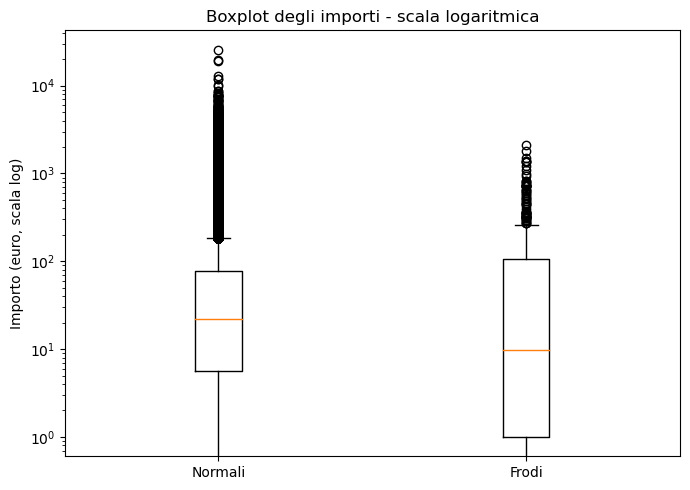

In [105]:
plt.figure(figsize=(7, 5))
plt.boxplot([df_pulito[df_pulito['Class']==0]['Amount'],
             df_pulito[df_pulito['Class']==1]['Amount']],
            labels=['Normali', 'Frodi'])
plt.yscale('log')
plt.title('Boxplot degli importi - scala logaritmica')
plt.ylabel('Importo (euro, scala log)')
plt.tight_layout()
plt.show()

Lo strumento è migliore per confrontare i due gruppi lungo tutto il range, e peggiore per
valutare la forma della distribuzione: il logaritmo comprime le distanze in modo non
uniforme - molto sui valori grandi, poco su quelli piccoli - quindi la scatola appare più
equilibrata di quanto sia e l'asimmetria non si legge più dal grafico.

Però questo grafico rende più evidenti due cose che la scala lineare nascondeva.

**Le frodi si estendono molto più in basso.** Q1 è a 1 euro contro i 5,67 delle normali:
sulla scala lineare quella parte era schiacciata contro l'asse e non si distingueva.

**I due gruppi differiscono di un ordine di grandezza sul massimo.** Le frodi si fermano a
2.126 euro, le normali arrivano a 25.691. Nessuna frode raggiunge gli importi estremi delle
transazioni legittime - un'informazione che nella tabella dei numeri c'era già, ma che qui
si coglie a colpo d'occhio.

Le mediane restano quelle calcolate: 22 euro per le normali, 9,82 per le frodi. Sulla scala
logaritmica cadono rispettivamente poco sopra e poco sotto il valore 10.

### Violin Plot
Somiglia a un boxplot ma invece della scatola disegna la forma della distribuzione: la larghezza in ogni punto indica quanti dati ci sono a quell'altezza. Largo dove i valori si addensano, stretto dove si diradano.

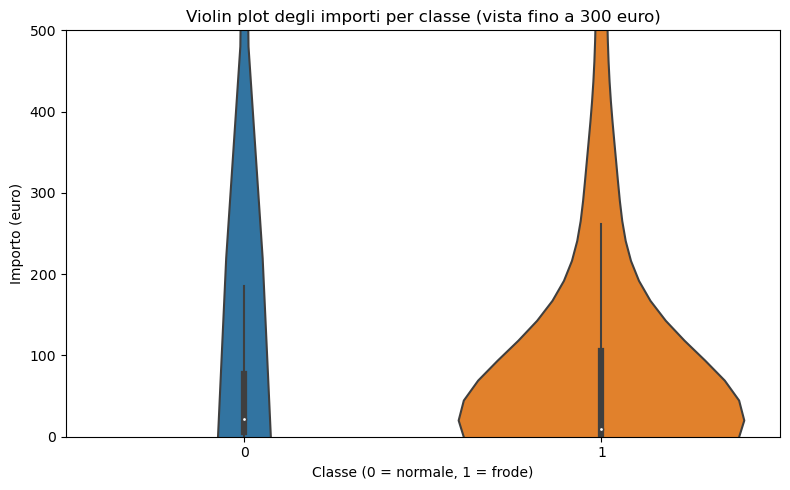

In [107]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_pulito, x='Class', y='Amount')
plt.ylim(0, 500)
plt.xlabel('Classe (0 = normale, 1 = frode)')
plt.ylabel('Importo (euro)')
plt.title('Violin plot degli importi per classe (vista fino a 500 euro)')
plt.tight_layout()
plt.show()

Il violin plot aggiunge l'informazione che al boxplot mancava: **la forma della
distribuzione.** La larghezza in ogni punto indica quanti dati si trovano a quell'altezza,
quindi si legge dove i valori si addensano e dove si diradano. Al centro resta comunque un
boxplot in miniatura con mediana e quartili.

Il confronto tra le due forme è netto. **Le transazioni normali disegnano una figura
stretta e affusolata**: la massa è concentrata nei primi decine di euro e si assottiglia
rapidamente salendo. **Le frodi disegnano una figura larga e panciuta** tra zero e
duecento euro, che solo dopo si restringe.

Ciò che un boxplot non può mostrare,
perché riassume la distribuzione in cinque numeri e perde tutto quello che sta in mezzo.

### 7.4. Il picco a 100 euro

Verifichiamo un'altra cosa: il picco di 100 euro delle frodi nell'istogramma sovrapposto 

In [85]:
frodi = df_pulito[df_pulito['Class'] == 1]

print("Importi più frequenti tra le frodi:\n")
print(frodi['Amount'].value_counts().head(10).to_string())

Importi più frequenti tra le frodi:

1.00     105
99.99     27
0.00      25
0.76      17
0.77      10
0.01       5
2.00       4
3.79       4
1.18       3
12.31      3


Il picco visibile nell'istogramma intorno ai 100 euro non e' un artefatto grafico:
corrisponde all'importo 99,99 che ricorre 27 volte tra le frodi.
Guardando gli importi più frequenti emergono due comportamenti distinti:

1. MICRO-IMPORTI RIPETUTI: 1,00 euro (105 volte), 0,76, 0,77, 0,01 e l'importo
    a zero (25 volte). L'importo a zero non è uno scambio di denaro ma
    un'autorizzazione: verifica che la carta sia attiva senza addebitare nulla.
    L'insieme è coerente con il card testing, cioè la verifica preliminare di
    una carta prima di utilizzarla. Trova conferma nel dato già rilevato in fase
    di completezza: tra le transazioni con Amount = 0 il tasso di frode è circa
    nove volte la media del dataset.

2. IMPORTO APPENA SOTTO SOGLIA: 99,99 euro, un centesimo sotto il valore tondo.
    In molti circuiti di pagamento i 100 euro rappresentano una soglia oltre la
    quale scattano controlli o autenticazioni aggiuntive. Restare appena sotto è
    un modo per evitarli.

Nota di metodo: si tratta di un'ipotesi interpretativa che andrebbe confermata
con il team antifrode, che conosce le soglie operative effettive. Sul piano
dell'analisi il fatto rilevante è che questi valori non seguono una
distribuzione continua ma si concentrano su punti specifici, ed è proprio
questa concentrazione a costituire segnale.

### 7.5. `Amount` basta da sola?

Rivediamo il confronto tra le due distribuzioni, ora che conosciamo i numeri:
la seconda domanda importante è se Amount da sola sia sufficiente a distinguere una frode.

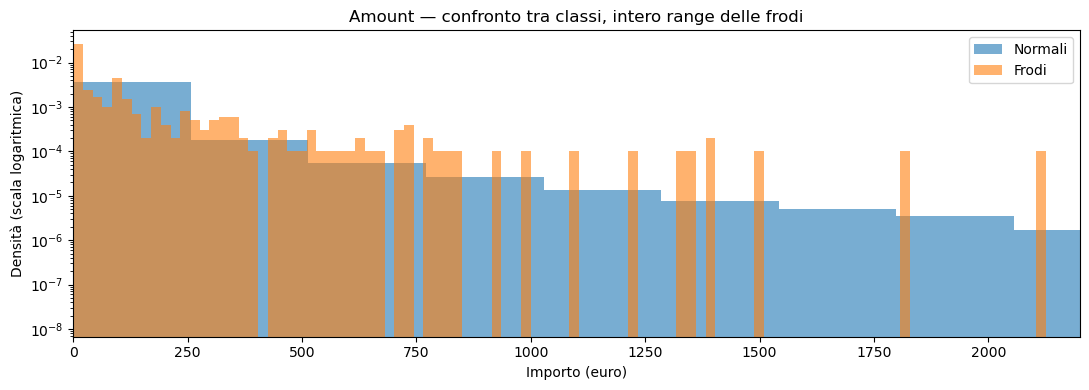

In [86]:
plt.figure(figsize=(11, 4))
plt.hist(df_pulito[df_pulito['Class']==0]['Amount'], bins=100, alpha=0.6, label='Normali', density=True)
plt.hist(df_pulito[df_pulito['Class']==1]['Amount'], bins=100, alpha=0.6, label='Frodi', density=True)
plt.yscale('log')
plt.xlim(0, 2200)
plt.xlabel('Importo (euro)')
plt.ylabel('Densità (scala logaritmica)')
plt.title('Amount — confronto tra classi, intero range delle frodi')
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# Cosa succederebbe usando "sotto 5 euro" come unico criterio?
sotto5 = df_pulito[df_pulito['Amount'] < 5]
frodi_prese = sotto5['Class'].sum()
falsi_allarmi = len(sotto5) - frodi_prese

print(f"Frodi intercettate:  {frodi_prese:,} su {df_pulito['Class'].sum():,}")
print(f"Falsi allarmi:       {falsi_allarmi:,}")
print(f"Rapporto:            {falsi_allarmi/frodi_prese:.0f} falsi allarmi per ogni frode")

Frodi intercettate:  210 su 473
Falsi allarmi:       66,973
Rapporto:            319 falsi allarmi per ogni frode


Amount mostra differenze statistiche significative tra le due classi,mediana
molto più bassa nelle frodi, concentrazione doppia sotto i 5 euro, valori
ricorrenti sospetti. Ma le due distribuzioni si sovrappongono ampiamente nella
fascia dove si concentra il 95% delle transazioni (fino a 365 euro, il 95° percentile calcolato sopra).

Amount da sola non è sufficiente a discriminare: usando 'sotto 5 euro' come
criterio si intercetterebbero 210 frodi generando oltre 67.000 falsi positivi.
Resta però una variabile informativa in combinazione con le altre: il segnale
non sta nell'importo in sè, ma nell'importo insieme al resto del profilo
della transazione.

### Istogramma della variabile trasformata con logaritmo

Il logaritmo comprime i valori grandi e lascia quasi intatti i piccoli. Un importo di 10 euro diventa circa 2,4; uno di 25.691 diventa circa 10,2. Il range passa da venticinquemila a dieci.

log1p calcola il logaritmo di uno più il valore: serve perché il logaritmo di zero non esiste, e qui ci sono 1.825 transazioni a importo zero.

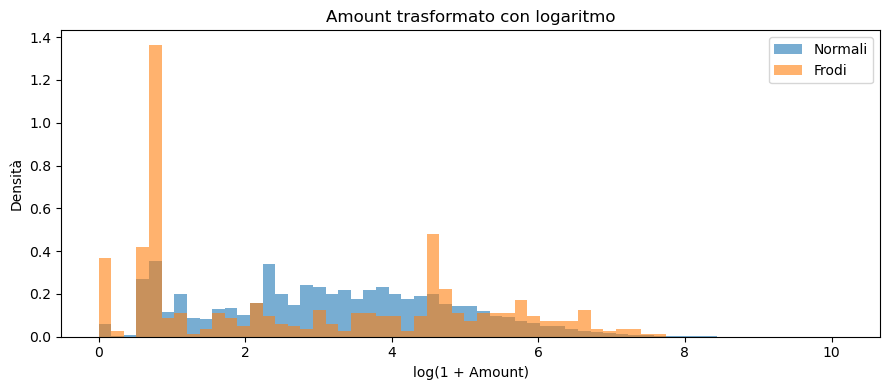

In [110]:
amount_log = np.log1p(df_pulito['Amount'])
bordi = np.linspace(amount_log.min(), amount_log.max(), 60)

plt.figure(figsize=(9, 4))
plt.hist(amount_log[df_pulito['Class']==0], bins=bordi, alpha=0.6, label='Normali', density=True)
plt.hist(amount_log[df_pulito['Class']==1], bins=bordi, alpha=0.6, label='Frodi', density=True)
plt.xlabel('log(1 + Amount)')
plt.ylabel('Densità')
plt.title('Amount trasformato con logaritmo')
plt.legend()
plt.tight_layout()
plt.show()

Questa è la rappresentazione più informativa delle altre.

**La trasformazione logaritmica funziona sulle transazioni normali.** L'azzurro forma una
campana larga e sostanzialmente simmetrica centrata intorno a 3-4, che è esattamente
l'effetto cercato: il logaritmo comprime i valori grandi e lascia quasi intatti i piccoli,
riportando un range di venticinquemila euro a un intervallo di dieci unità. Su questa
variabile trasformata i metodi standard di outlier detection tornerebbero applicabili.

**Sulle frodi la trasformazione non produce lo stesso effetto**, e il motivo è la scoperta
più rilevante di questa sezione: le frodi non seguono una distribuzione continua. L'arancione
è una campana bassa sormontata da tre picchi verticali, cioè valori specifici che si
ripetono identici.

I tre picchi corrispondono ai fenomeni già individuati separatamente nelle sezioni
precedenti:

| Posizione | Importo | Cosa rappresenta |
|---|---|---|
| ~0 | 0,00 € | le autorizzazioni a importo zero, sezione 3 |
| ~0,7 | 1,00 € | il micro-importo ricorrente, 105 occorrenze |
| ~4,6 | 99,99 € | il valore appena sotto la soglia dei 100 euro |

I valori sull'asse sono logaritmi: log(1+1) fa circa 0,69 e log(1+100) circa 4,6, da cui
la posizione dei picchi.

**Il grafico mostra quindi in un colpo solo tre fenomeni che erano emersi in momenti
diversi dell'analisi** - e li mostra come manifestazioni di una stessa cosa: la
concentrazione delle frodi su valori specifici anziché su un intervallo continuo. È
precisamente il tipo di segnale che un modello ad albero può sfruttare, perché lavora per
soglie.

## 8. La variabile `Time`

In [88]:
df_pulito['Time'].describe().round(2)

count    283726.00
mean      94811.08
std       47481.05
min           0.00
25%       54204.75
50%       84692.50
75%      139298.00
max      172792.00
Name: Time, dtype: float64

Secondo la documentazione del dataset, `Time` contiene i secondi trascorsi dalla prima transazione; il valore massimo di 172.792 è coerente con le due giornate dichiarate (172.800 secondi)

Un giorno ha 86.400 secondi: 24 ore per 60 minuti per 60 secondi.
Due giorni fanno 172.800. Il massimo di Time è 172.792 (otto secondi in meno).

Quindi `Time` è il numero di secondi trascorsi dalla prima transazione del dataset. Non è un orario reale: è un contatore che parte da zero.

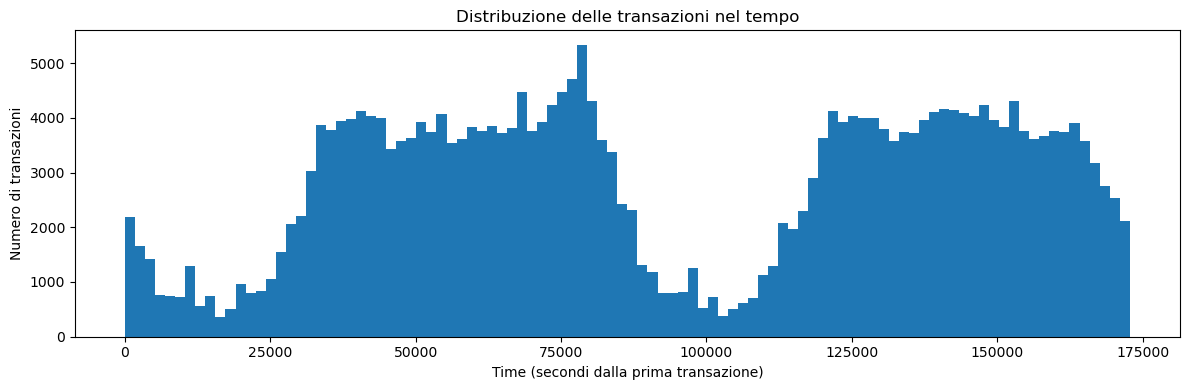

In [89]:
plt.figure(figsize=(12, 4))

plt.hist(df_pulito['Time'], bins=100)
plt.xlabel('Time (secondi dalla prima transazione)')
plt.ylabel('Numero di transazioni')
plt.title('Distribuzione delle transazioni nel tempo')

plt.tight_layout()
plt.show()

Ci sono due avvallamenti che potrebbe coincidere con l'orario notturno

In [90]:
# I due avvallamenti si individuano cercando il minimo di transazioni per fascia oraria,
# separatamente nella prima e nella seconda metà del periodo osservato.

conteggi, bordi = np.histogram(df_pulito['Time'], bins=100)
centri = (bordi[:-1] + bordi[1:]) / 2

meta = len(conteggi) // 2
min1 = centri[np.argmin(conteggi[:meta])]
min2 = centri[meta:][np.argmin(conteggi[meta:])]

print(f"Primo minimo:   {min1:>10,.0f} secondi")
print(f"Secondo minimo: {min2:>10,.0f} secondi")
print(f"Differenza:     {min2-min1:>10,.0f} secondi  ({(min2-min1)/3600:.1f} ore)")
print(f"Un giorno:          86,400 secondi  (24 ore)")

Primo minimo:       16,415 secondi
Secondo minimo:    102,811 secondi
Differenza:         86,396 secondi  (24.0 ore)
Un giorno:          86,400 secondi  (24 ore)


Le due gobbe separate da avvallamenti, l'ipotesi che i cali corrispondano alle ore notturne, e la verifica che tra i due minimi passano 86.396 secondi, praticamente 24 ore esatte.

### 8.1 Costruiamo la variabile `ora`

In [91]:
df_pulito['Ora'] = (df_pulito['Time'] // 3600) % 24

# Verifica della trasformazione: deve coprire tutte le 24 ore
print(f"Valori distinti: {df_pulito['Ora'].nunique()}")
print(f"Minimo: {df_pulito['Ora'].min()}  Massimo: {df_pulito['Ora'].max()}")

Valori distinti: 24
Minimo: 0.0  Massimo: 23.0


### 8.2 Le frodi si concentrano in certe fasce orarie?

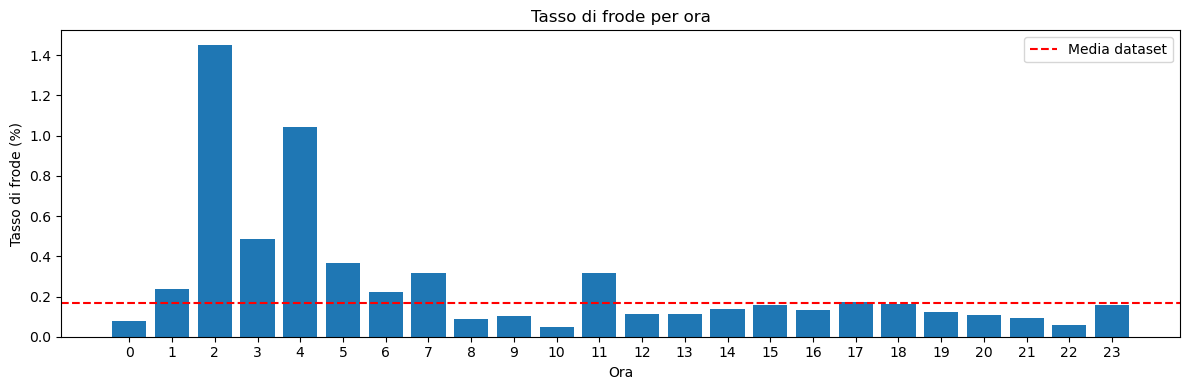

In [92]:
tasso_orario = df_pulito.groupby('Ora')['Class'].mean() * 100

plt.figure(figsize=(12, 4))
plt.bar(tasso_orario.index, tasso_orario.values)
plt.axhline(df_pulito['Class'].mean()*100, color='red', linestyle='--', label='Media dataset')
plt.xlabel('Ora')
plt.ylabel('Tasso di frode (%)')
plt.title('Tasso di frode per ora')
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

In [93]:
verifica = df_pulito.groupby('Ora').agg(
    transazioni=('Class', 'size'),
    frodi=('Class', 'sum'),
    tasso_pct=('Class', lambda x: x.mean()*100)
).round(2)

print(verifica.sort_values('tasso_pct', ascending=False).head(8))

      transazioni  frodi  tasso_pct
Ora                                
2.0          3308     48       1.45
4.0          2204     23       1.04
3.0          3487     17       0.49
5.0          2988     11       0.37
7.0          7233     23       0.32
11.0        16781     53       0.32
1.0          4208     10       0.24
6.0          4082      9       0.22


Le frodi si concentrano nelle ore notturne: alle 2 il tasso è dell'1,45% contro lo 0,17%
medio del dataset, **quasi 9 volte più alto** (tenendo i duplicati questo risultava 10 volte la media, 9 frodi duplicate su 19 totali stavano tutte lì.). Alle 4 è dell'1,04%, sei volte la media.

L'osservazione regge alla verifica sui volumi: alle 2 ci sono 48 frodi su 3.308 transazioni.
Non è un tasso costruito su pochi casi, quelle 48 frodi sono oltre il 10% di tutte le frodi (492 con duplicati, 473 senza)
del dataset, concentrate in una sola ora.

Va però distinto il tasso dal volume assoluto. Alle 11 le frodi sono 53, di più che alle 2, ma il tasso scende allo 0,32% perché le transazioni totali sono cinque volte
tante. Le due misure rispondono a domande diverse: **il tasso dice quanto è rischiosa una
singola transazione in quell'ora, il conteggio dice dove si concentra il danno.**

**L'ora appare quindi una variabile informativa: la terrei nel modello.**

## 9. Le variabili `V1-V28`

Sono componenti PCA: il significato originale non lo consocciamo, quindi non è possibile interpretarle nel merito. Resta però una domanda praticabile: **quali di queste variabili separano le frodi dalle transazioni normali?**

In [95]:
colonne_v = [c for c in df_pulito.columns if c.startswith('V')]

confronto_v = df_pulito.groupby('Class')[colonne_v].mean().T
confronto_v.columns = ['Normali', 'Frodi']
confronto_v['differenza'] = (confronto_v['Frodi'] - confronto_v['Normali']).abs()

print(confronto_v.sort_values('differenza', ascending=False).round(2).head(28))

     Normali  Frodi  differenza
V14     0.01  -6.84        6.85
V3      0.01  -6.73        6.74
V17     0.01  -6.46        6.47
V12     0.01  -6.10        6.11
V10     0.01  -5.45        5.46
V7      0.01  -5.18        5.19
V1      0.01  -4.50        4.51
V4     -0.01   4.47        4.48
V16     0.01  -4.00        4.01
V11    -0.01   3.72        3.72
V2     -0.01   3.41        3.42
V5      0.01  -2.96        2.96
V9      0.00  -2.52        2.52
V18     0.01  -2.16        2.16
V6      0.00  -1.43        1.43
V8     -0.00   0.95        0.96
V19    -0.00   0.67        0.67
V21    -0.00   0.47        0.47
V20    -0.00   0.41        0.41
V27     0.00   0.21        0.21
V24     0.00  -0.11        0.11
V23     0.00  -0.10        0.10
V13     0.00  -0.09        0.10
V22    -0.00   0.09        0.09
V28     0.00   0.08        0.08
V15     0.00  -0.07        0.07
V26     0.00   0.05        0.05
V25    -0.00   0.04        0.04


Il confronto tra le medie mostra una separazione netta.

Nelle transazioni normali tutte le V hanno media praticamente nulla, conseguenza della
PCA, che centra le componenti sulla media, unita al fatto che le normali costituiscono
il 99,83% del dataset.

Nelle frodi invece alcune variabili si discostano fortemente: **V14, V3, V17, V12, V10
mostrano differenze tra 5 e 7 punti**. Dalla V8 in giù le differenze scendono sotto
l'unità, e le ultime, V22, V23, V25, V26, sono praticamente identiche nei due gruppi.

Circa metà delle componenti non sembra quindi portare informazione utile a distinguere
le classi.

**NOTA:** il confronto è stato fatto sulle medie e due gruppi possono
avere la stessa media pur essendo distribuiti in modo molto diverso. Una media simile non
implica automaticamente che la variabile sia inutile. Per una prima esplorazione
l'indicatore è ragionevole, dice dove guardare per prime, ma la conferma andrà cercata
osservando le distribuzioni complete e, nel notebook successivo, confrontando questa
classifica con la feature importance del modello.

### 9.1 Verifica sulle distribuzioni

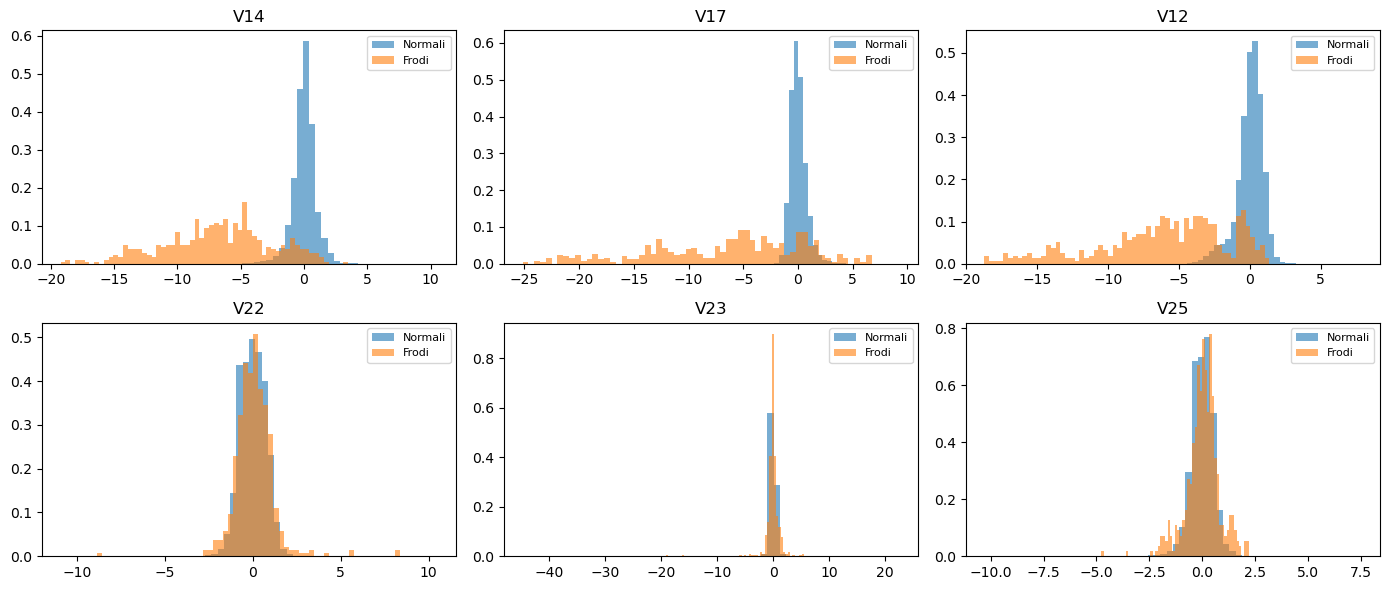

In [100]:
variabili = ['V14', 'V17', 'V12', 'V22', 'V23', 'V25']

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for ax, v in zip(axes.flat, variabili):
    ax.hist(df_pulito[df_pulito['Class']==0][v], bins=60, alpha=0.6, label='Normali', density=True)
    ax.hist(df_pulito[df_pulito['Class']==1][v], bins=60, alpha=0.6, label='Frodi', density=True)
    ax.set_title(v)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [97]:
print(df_pulito.groupby('Class')['V23'].agg(['count', 'mean', 'std', 'min', 'max']).round(2))

        count  mean   std    min    max
Class                                  
0      283253   0.0  0.62 -44.81  22.53
1         473  -0.1  1.51 -19.25   5.47


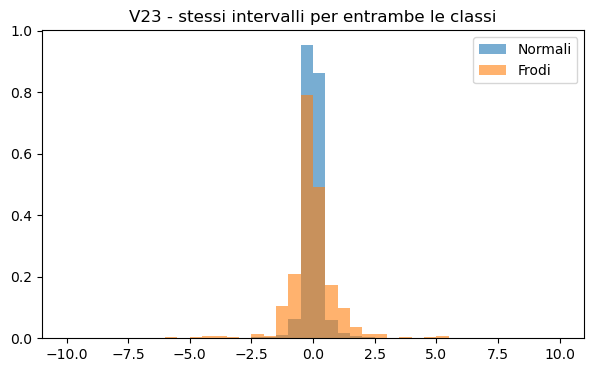

In [102]:
import numpy as np
bordi = np.linspace(-10, 10, 41)

plt.figure(figsize=(7, 4))
plt.hist(df_pulito[df_pulito['Class']==0]['V23'], bins=bordi, alpha=0.6, label='Normali', density=True)
plt.hist(df_pulito[df_pulito['Class']==1]['V23'], bins=bordi, alpha=0.6, label='Frodi', density=True)
plt.legend()
plt.title('V23 - stessi intervalli per entrambe le classi')
plt.show()

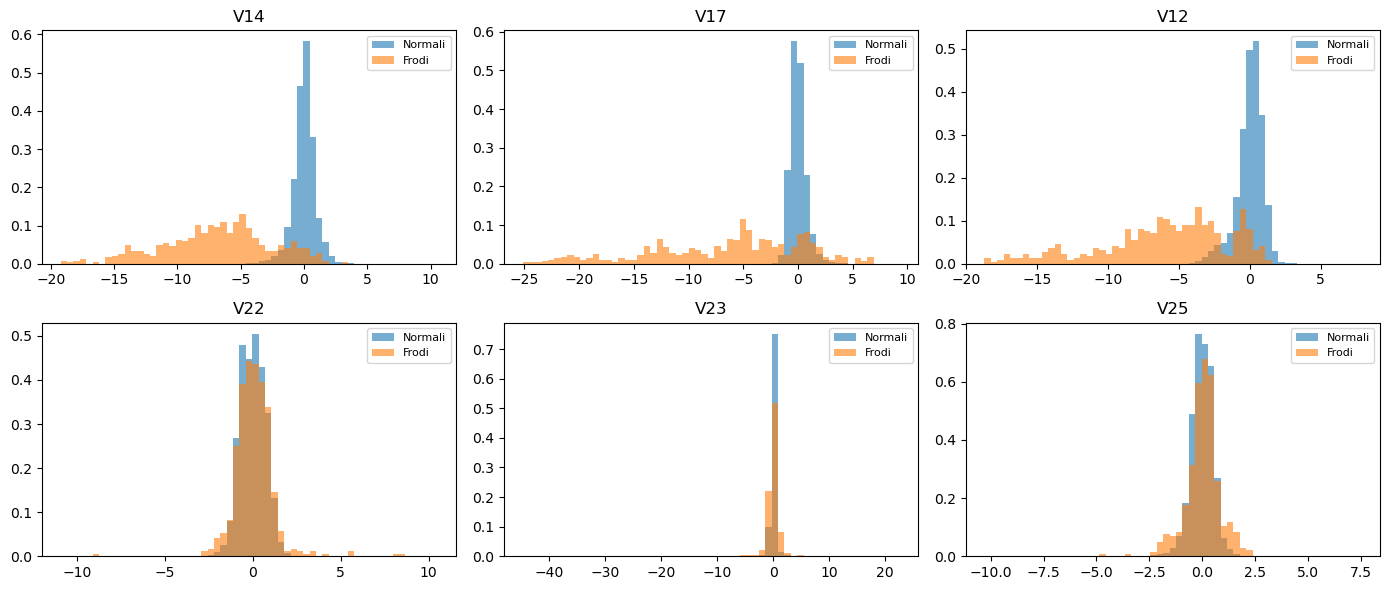

In [103]:
# Gli intervalli vanno forzati identici per entrambe le classi: matplotlib altrimenti
# li calcola separatamente su ciascuna serie, e con range diversi le larghezze risultano
# diverse. Con density=True intervalli più stretti producono barre più alte, quindi le
# altezze non sarebbero confrontabili.

variabili = ['V14', 'V17', 'V12', 'V22', 'V23', 'V25']

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for ax, v in zip(axes.flat, variabili):
    # intervalli comuni calcolati sull'intero range della variabile
    bordi = np.linspace(df_pulito[v].min(), df_pulito[v].max(), 60)
    ax.hist(df_pulito[df_pulito['Class']==0][v], bins=bordi, alpha=0.6, label='Normali', density=True)
    ax.hist(df_pulito[df_pulito['Class']==1][v], bins=bordi, alpha=0.6, label='Frodi', density=True)
    ax.set_title(v)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Nota: gli intervalli sono stati forzati identici per entrambe le classi. Con il calcolo automatico, avendo le due serie range diversi, matplotlib produceva intervalli di larghezza diversa — e con density=True intervalli più stretti generano barre più alte. Su V23 questo produceva un picco apparente nelle frodi che risultava dalla normalizzazione e non dai dati.

Il confronto è fatto su sei variabili scelte come rappresentative: nella riga superiore
V14, V17 e V12, le tre con la differenza tra medie più alta, nella riga inferiore V22,
V23 e V25, tra quelle con differenza quasi nulla.

**Nella riga superiore le due distribuzioni occupano posizioni diverse.** Le transazioni
normali formano una guglia stretta attorno allo zero, mentre le frodi si distribuiscono
su una massa larga spostata verso valori negativi. Su V14 le frodi si collocano
prevalentemente tra -20 e -5, dove le normali sono quasi assenti.

**Nella riga inferiore le due distribuzioni si sovrappongono quasi completamente:** stessa
posizione, stessa forma. Conoscere il valore di queste variabili non aiuta a distinguere
una frode.

I grafici confermano quindi il confronto tra medie: dove la differenza era marcata le
distribuzioni sono effettivamente separate, dove era nulla si sovrappongono. Lo strumento
indiretto, la media, aveva dato la risposta corretta, e ora lo sappiamo per verifica e
non per assunzione.

**Un elemento che le medie non potevano mostrare:** le frodi hanno distribuzioni molto più
larghe. Su V14 le transazioni normali stanno compresse tra -2 e +2, mentre le frodi si
spalmano su una ventina di punti. Non è solo una questione di posizione diversa: le frodi
sono anche molto più disperse, il che suggerisce comportamenti irregolari piuttosto che un
diverso tipo di regolarità.

## 10. Correlazioni

In [114]:
correlazioni = df_pulito.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

print("Correlazione con Class - prime dieci in valore assoluto:\n")
print(correlazioni.head(50).round(3).to_string())

Correlazione con Class - prime dieci in valore assoluto:

V17      -0.313
V14      -0.293
V12      -0.251
V10      -0.207
V16      -0.187
V3       -0.182
V7       -0.172
V11       0.149
V4        0.129
V18      -0.105
V1       -0.094
V9       -0.094
V5       -0.088
V2        0.085
V6       -0.044
V19       0.034
V8        0.033
V21       0.026
V27       0.022
V20       0.021
Ora      -0.017
Time     -0.012
V28       0.010
V24      -0.007
V23      -0.006
Amount    0.006
V22       0.005
V26       0.004
V13      -0.004
V15      -0.003
V25       0.003


In [115]:
medie = confronto_v['differenza'].sort_values(ascending=False).head(10).index.tolist()
corr = correlazioni.head(10).index.tolist()

print("Per differenza tra medie:", medie)
print("Per correlazione:       ", corr)
print()
print("In entrambe:", sorted(set(medie) & set(corr)))
print("Solo medie: ", sorted(set(medie) - set(corr)))
print("Solo corr:  ", sorted(set(corr) - set(medie)))

Per differenza tra medie: ['V14', 'V3', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4', 'V16', 'V11']
Per correlazione:        ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

In entrambe: ['V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V3', 'V4', 'V7']
Solo medie:  ['V1']
Solo corr:   ['V18']


La correlazione misura quanto due variabili si muovono insieme, su una scala da -1 a +1.
Applicata al target risponde a una domanda simile a quella del confronto tra medie - quali
variabili sono associate alla frode - ma per una strada diversa, quindi vale la pena
confrontare i risultati.

Sulle V1–V28 non ha senso guardare le correlazioni reciproche: essendo componenti PCA sono
ortogonali per costruzione, quindi decorrelate tra loro. La matrice sarebbe vuota.

### Il risultato

Le variabili più correlate con `Class` sono V17 (-0,313), V14 (-0,293), V12 (-0,251),
V10 (-0,207) e V16 (-0,187). Sono le stesse che emergevano dal confronto tra medie: nove
su dieci coincidono, e l'unica divergenza riguarda V1 e V18, entrambe al confine della
classifica.

**Cambia però l'ordine interno.** Per differenza tra medie V14 veniva prima, per
correlazione viene V17; e V16 sale dal nono al quinto posto. Le due misure guardano cose
diverse: la differenza tra medie dice quanto sono distanti i due centri, la correlazione
dice quanto il valore si muove insieme al target tenendo conto anche della dispersione. Una
variabile può avere medie distanti ma essere molto dispersa in entrambi i gruppi, e allora
la separazione conta meno di quanto sembri.

### Nessun predittore forte

**Il valore più alto è -0,313.** Su una scala che arriva a 1, un terzo è una correlazione
debole-moderata: nessuna variabile, presa da sola, spiega la frode.

`Amount` si ferma a 0,006, il che conferma quantitativamente quanto già emerso - le
distribuzioni si sovrappongono, e il criterio "sotto 5 euro" produceva 319 falsi allarmi
per ogni frode intercettata.

### Il limite dello strumento sulle variabili cicliche

`Time` e `Ora` hanno correlazioni entrambe vicine a zero (-0,012 e -0,017), ma per ragioni
diverse.

`Time` è un contatore crescente: la correlazione misura se le frodi tendano a concentrarsi
all'inizio o alla fine del periodo osservato, e giustamente non trova nulla.

`Ora` invece è **ciclica**: va da 0 a 23 e ricomincia. La correlazione di Pearson misura
relazioni lineari e non sa che dopo il 23 viene lo 0 - vede solo se al crescere del numero
cresca anche la probabilità di frode.

**Quindi `Ora` risulta non correlata pur avendo un picco di nove volte la media alle 2 di
notte.** Il segnale esiste, ma non è di tipo lineare, e questo strumento non lo misura. È
lo stesso limite per cui un modello lineare non coglierebbe una relazione a U.

### Conclusione

Nessun predittore forte preso singolarmente, e alcune variabili informative in modi che la
correlazione lineare non misura. Il segnale non sta in una variabile ma nella loro
combinazione — il che orienta verso modelli capaci di cogliere interazioni e relazioni non
lineari, come quelli ad albero.

Restano nove variabili su cui due metodi indipendenti concordano: V3, V4, V7, V10, V11,
V12, V14, V16, V17. Nel notebook successivo questa lista andrà confrontata con la feature
importance del modello.

## 11. Interazioni tra Variabili

### 11.1 Le due componenti più informative - `V17`, `V14`

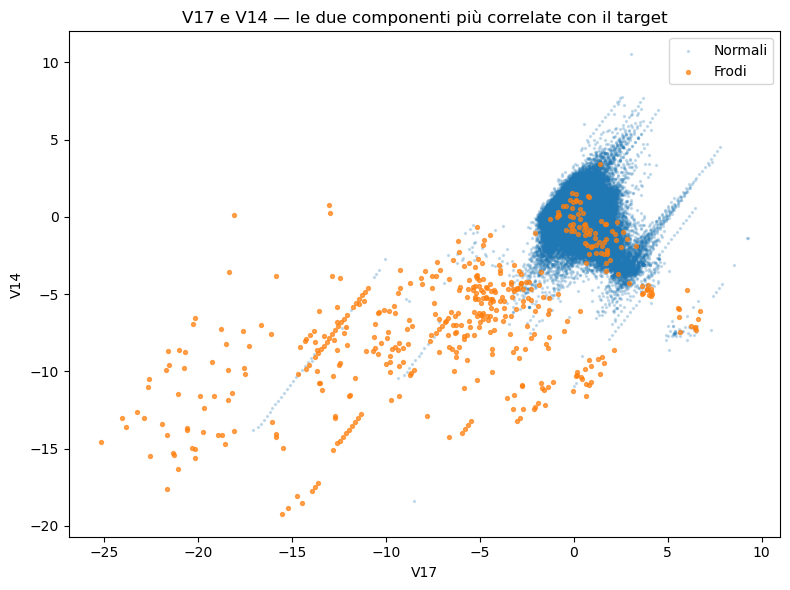

In [116]:
plt.figure(figsize=(8, 6))

plt.scatter(df_pulito[df_pulito['Class']==0]['V17'],
            df_pulito[df_pulito['Class']==0]['V14'],
            s=2, alpha=0.2, label='Normali')
plt.scatter(df_pulito[df_pulito['Class']==1]['V17'],
            df_pulito[df_pulito['Class']==1]['V14'],
            s=8, alpha=0.7, label='Frodi')

plt.xlabel('V17')
plt.ylabel('V14')
plt.title('V17 e V14 — le due componenti più correlate con il target')
plt.legend()
plt.tight_layout()
plt.show()

Ogni punto è una transazione, posizionata secondo il valore di V17 in orizzontale e V14 in
verticale. Le normali sono disegnate piccolissime e molto trasparenti: con 283.253 punti
sovrapposti, senza trasparenza si vedrebbe solo una macchia uniforme.

**Le transazioni normali formano una massa compatta** attorno all'origine, contenuta
grossomodo tra -3 e +5 su entrambi gli assi. **Le frodi occupano una regione distinta** in
basso a sinistra: valori negativi su entrambe le componenti, distribuite lungo una
diagonale che si estende fino a -25 e -20.

**Il punto rilevante è il quadrante in basso a sinistra**, dove ci sono decine di frodi e
quasi nessuna transazione normale. È una regione dello spazio che appartiene in modo
pressoché esclusivo alle frodi.

Ma nessuna delle due variabili la identificherebbe da sola. Un valore di V17 pari a -10 non
basta a decidere, e nemmeno un V14 pari a -8: è la **combinazione** dei due a isolare quella
zona. È la dimostrazione visiva di quanto emerso dalle correlazioni - nessun predittore
forte singolarmente, ma segnale nella combinazione.

**Va però osservato anche il rovescio.** Una parte delle frodi si trova dentro la massa
azzurra, indistinguibile dalle transazioni normali su queste due dimensioni. Quelle
richiederanno le altre variabili per essere separate - nessuna coppia, per quanto
informativa, esaurisce il problema.

Questo orienta la scelta del modello: **gli algoritmi ad albero lavorano esattamente così**,
tagliando lo spazio su una variabile e poi, dentro ciascun ramo, su un'altra. È il
meccanismo che permette di isolare regioni che nessun taglio singolo troverebbe.

### 11.2 Ora e importo insieme
La domanda: le frodi nella fascia a maggior rischio hanno importi diversi?

In [117]:
# Divido le frodi tra fascia 2-4, quella con tasso più alto, e resto della giornata
frodi = df_pulito[df_pulito['Class'] == 1]
notturne = frodi[frodi['Ora'].between(2, 4)]
diurne = frodi[~frodi['Ora'].between(2, 4)]

print(f"{'':22} {'notturne':>10} {'altre ore':>10}")
print(f"{'Numero di frodi':22} {len(notturne):>10,} {len(diurne):>10,}")
print(f"{'Importo mediano':22} {notturne['Amount'].median():>10.2f} {diurne['Amount'].median():>10.2f}")
print(f"{'Importo medio':22} {notturne['Amount'].mean():>10.2f} {diurne['Amount'].mean():>10.2f}")
print(f"{'Sotto 5 euro':22} {(notturne['Amount']<5).mean()*100:>9.1f}% {(diurne['Amount']<5).mean()*100:>9.1f}%")

                         notturne  altre ore
Numero di frodi                88        385
Importo mediano              1.00      19.59
Importo medio               62.90     137.81
Sotto 5 euro                65.9%      39.5%


### 13.2 Le frodi nella fascia a maggior rischio hanno importi diversi?

La sezione 9 aveva individuato una concentrazione di frodi nelle ore 2–4, con un tasso
fino a nove volte la media. La domanda che ne discende: si tratta delle stesse frodi
distribuite diversamente nel tempo, oppure di un comportamento distinto?

Il confronto è tra le frodi avvenute nella fascia 2–4 e tutte le altre.

| | fascia 2–4 | altre ore |
|---|---|---|
| Numero di frodi | 88 | 385 |
| Importo mediano | 1,00 € | 19,59 € |
| Importo medio | 62,90 € | 137,81 € |
| Sotto 5 euro | 65,9% | 39,5% |

**Le due popolazioni sono nettamente diverse.** L'importo mediano nella fascia a maggior
rischio è di 1 euro contro i 19,59 delle altre ore: venti volte tanto. E i due terzi delle
frodi in quella fascia stanno sotto i 5 euro, contro meno di due quinti nel resto della
giornata.

Non sono quindi le stesse frodi spostate di orario: **sono due comportamenti distinti.**
Nella fascia 2–4 prevalgono le micro-transazioni, altrove gli importi sono più consistenti.

**Questo risultato ricompone tre osservazioni finora separate:** le autorizzazioni a importo
zero con tasso di frode nove volte la media (sezione 3), i micro-importi ricorrenti - 1,00
euro per 105 volte, 0,76, 0,01 (sezione 8), e la concentrazione oraria (sezione 10). Erano
tre indizi indipendenti; insieme descrivono un unico fenomeno, quello che la conoscenza di
dominio identifica come *card testing*: la verifica preliminare di una carta rubata, che
avviene con importi minimi e si concentra in una fascia oraria precisa.

**Resta un'ipotesi interpretativa.** I dati mostrano la concentrazione e la distinzione tra
le due popolazioni; l'attribuzione al card testing viene dal funzionamento dei circuiti di
pagamento, non dai numeri. E non è nemmeno accertato che la fascia 2–4 corrisponda alle ore
notturne: `Time` parte dall'inizio della raccolta, non da mezzanotte. La conferma
richiederebbe il referente di business.

### 11.3 Il tasso di frode cambia con l'importo?

In [118]:
fasce = [0, 1, 5, 20, 50, 100, 200, 500, 1000, df_pulito['Amount'].max()]
etichette = ['0-1', '1-5', '5-20', '20-50', '50-100', '100-200', '200-500', '500-1000', '>1000']

df_pulito['FasciaImporto'] = pd.cut(df_pulito['Amount'], bins=fasce,
                                     labels=etichette, include_lowest=True)

rischio = df_pulito.groupby('FasciaImporto', observed=True).agg(
    transazioni=('Class', 'size'),
    frodi=('Class', 'sum'),
    tasso_pct=('Class', lambda x: x.mean()*100)
).round(3)

print(rischio)

               transazioni  frodi  tasso_pct
FasciaImporto                               
0-1                  30331    171      0.564
1-5                  38416     40      0.104
5-20                 69742     49      0.070
20-50                51659     33      0.064
50-100               37179     55      0.148
100-200              27629     43      0.156
200-500              19661     48      0.244
500-1000              6174     25      0.405
>1000                 2935      9      0.307


È la stessa domanda posta per l'ora nella sezione 10, applicata ad `Amount`: non come si
distribuiscono le frodi, ma quale fascia di importo risulti più rischiosa.

Le fasce non sono equidistanti: sono strette dove i dati si addensano - sotto i cento euro
sta la grande maggioranza delle transazioni - e larghe dove si diradano. Dividere in
intervalli uguali produrrebbe fasce alte con decine di migliaia di casi e fasce alte con
poche unità.

| Fascia | Transazioni | Frodi | Tasso |
|---|---|---|---|
| 0–1 € | 30.331 | 171 | **0,564%** |
| 1–5 € | 38.416 | 40 | 0,104% |
| 5–20 € | 69.742 | 49 | 0,070% |
| 20–50 € | 51.659 | 33 | **0,064%** |
| 50–100 € | 37.179 | 55 | 0,148% |
| 100–200 € | 27.629 | 43 | 0,156% |
| 200–500 € | 19.661 | 48 | 0,244% |
| 500–1000 € | 6.174 | 25 | **0,405%** |
| oltre 1000 € | 2.935 | 9 | 0,307% |

**Il tasso non decresce in modo regolare: descrive una U.**

Parte dallo 0,564% nella fascia sotto l'euro, oltre tre volte la media del dataset. Crolla
al minimo tra 5 e 50 euro, dove scende allo 0,064% - al di **sotto** della media generale.
Poi risale progressivamente fino allo 0,405% nella fascia 500–1000.

Le transazioni più rischiose sono quindi quelle di importo minimo e quelle elevate. Quelle
di importo ordinario — tra 5 e 50 euro, dove passa la maggior parte del traffico - sono le
più sicure.

### Perché questo spiega la correlazione quasi nulla

La correlazione di `Amount` con il target era 0,006, praticamente zero. Ora se ne capisce
il motivo: **la correlazione misura relazioni lineari**, cioè cerca se al crescere
dell'importo il rischio cresca o cali in modo costante. Qui il rischio prima scende e poi
risale, e i due movimenti si annullano nel calcolo.

**`Amount` è quindi informativa, ma non in modo lineare** - esattamente come `Ora`, seppure
per una ragione diversa: lì il problema era la ciclicità, qui è il cambio di direzione.

È la stessa situazione della relazione a U tra età e rischio di credito: un modello lineare
può solo dire "più importo, più rischio" oppure il contrario, e in entrambi i casi
sbaglierebbe su metà della curva. Un modello ad albero taglia dove serve, e può cogliere che
sia gli importi minimi sia quelli alti sono a rischio mentre quelli intermedi non lo sono.

Le due variabili leggibili del dataset risultano quindi entrambe utili, ma nessuna delle due
lo dimostra attraverso la correlazione lineare - il che è una ragione in più per non usare
quel solo indicatore per decidere cosa tenere.

## 12. Riepilogo

## 14. Riepilogo

### Qualità del dato

**Struttura coerente.** Tutte le colonne sono numeriche e prive di valori nulli. I tipi
sono adeguati al contenuto, con l'eccezione di `Time`, dichiarata `float64` ma contenente
valori interi. Le V1–V28 non sono interpretabili nel merito perché risultato di una
trasformazione PCA, ma i valori sono coerenti con quanto dichiarato nella documentazione.

**Duplicati.** 1.081 righe duplicate esatte, distribuite in modo molto disomogeneo: il 3,9%
delle frodi contro lo 0,37% delle transazioni normali, dieci volte tanto. Il problema si
concentra dove il dataset è più fragile. Rimossi creando `df_pulito`, mantenendo la versione
originale per il confronto sull'impatto della qualità del dato previsto nel notebook 2.

**Completezza sostanziale.** Nessun valore nullo, ma 1.825 transazioni con importo a zero,
tra cui il tasso di frode è dell'1,48% - nove volte la media. Mantenute in attesa di
conferma sulla semantica del campo.

### Il problema

**Forte sbilanciamento:** una frode ogni 578 transazioni, lo 0,17%. Con questa proporzione
l'accuracy è inutile - un modello che rispondesse sempre "non è frode" otterrebbe il 99,83%.
La valutazione dovrà basarsi su Recall e AUC-ROC.

### `Amount`

**Dominio coerente**, nessun valore negativo, coerente con l'ipotesi che si tratti di
importi di pagamenti con carta.

**Distribuzione fortemente asimmetrica:** mediana 22 euro contro una media di 88, massimo
25.691. Il metodo IQR classifica come outlier l'11,2% delle transazioni - dimostrazione che
la regola dell'1,5 non è applicabile a distribuzioni con code lunghe. Da qui la scelta di
`RobustScaler` invece di `StandardScaler` in fase di modellazione: media e deviazione
standard sono distorte dalla coda, mediana e IQR no.

**Le frodi si concentrano sugli importi bassi** - 44,4% sotto i 5 euro contro il 23,6% delle
normali - e mostrano valori ricorrenti: 1,00 euro ripetuto 105 volte, l'importo a zero 25
volte, e 99,99 euro 27 volte, un centesimo sotto una soglia tonda.

**Da sola non discrimina:** usando "sotto 5 euro" come criterio si intercetterebbero 210
frodi generando 66.973 falsi allarmi - 319 per ogni frode trovata.

**Ma il tasso di frode per fascia di importo descrive una U:** 0,564% sotto l'euro, minimo
allo 0,064% tra 20 e 50 euro, poi risalita fino allo 0,405% nella fascia 500–1000. Le
transazioni di importo minimo e quelle elevate sono le più rischiose; quelle ordinarie le più
sicure.

### `Time` e `Ora`

**Contatore in secondi** dalla prima transazione, copre due giornate. La distribuzione mostra
un ciclo giornaliero netto: due avvallamenti distanti 86.396 secondi, praticamente 24 ore
esatte.

**La variabile derivata `Ora`** evidenzia una concentrazione di frodi nella fascia 2-4: alle
2 il tasso è dell'1,45%, quasi nove volte la media, su 48 frodi - oltre il 10% di tutte le
frodi del dataset in un'unica ora. Il fenomeno è reale ma la sua entità era sovrastimata dai
duplicati: nove delle 19 frodi duplicate stavano proprio lì.

**Va distinto il tasso dal volume assoluto:** alle 11 le frodi sono 53, più che alle 2, ma il
tasso scende allo 0,32% perché le transazioni totali sono cinque volte tante. Il tasso dice
quanto è rischiosa una singola transazione, il conteggio dove si concentra il danno.

### `V1`–`V28`

**Circa metà delle componenti non mostra differenze apprezzabili tra le classi.** Le più
informative risultano V14, V3, V17, V12 e V10, con differenze tra medie comprese tra 5 e 7
punti. La verifica sulle distribuzioni conferma il confronto tra medie.

**Nove variabili su cui due metodi indipendenti concordano** - differenza tra medie e
correlazione con il target: V3, V4, V7, V10, V11, V12, V14, V16, V17.

### Correlazioni

**Nessun predittore forte:** il valore più alto è -0,313 su V17. `Amount` si ferma a 0,006,
`Ora` a -0,017.

**Ma la correlazione lineare non è lo strumento adatto per queste due variabili.** `Ora` è
ciclica - dopo il 23 viene lo 0 - e `Amount` ha una relazione a U. In entrambi i casi il
segnale esiste ma non è lineare, e viene misurato a zero. È una ragione per non usare la sola
correlazione come criterio di selezione delle variabili.

### Interazioni

**Lo scatter di V17 contro V14** mostra una regione in basso a sinistra occupata quasi
esclusivamente dalle frodi. Nessuna delle due variabili la identificherebbe da sola: è la
combinazione a isolarla. Una parte delle frodi resta però dentro la massa delle normali, e
richiederà le altre variabili.

**Le frodi nella fascia 2–4 hanno un profilo distinto:** importo mediano di 1 euro contro i
19,59 delle altre ore, e il 65,9% sotto i 5 euro contro il 39,5%. Non sono le stesse frodi
spostate di orario, sono un comportamento diverso.

**Tre osservazioni indipendenti convergono:** le autorizzazioni a importo zero, i
micro-importi ricorrenti e la concentrazione oraria descrivono un unico fenomeno, che la
conoscenza di dominio identifica come *card testing* - la verifica preliminare di una carta
rubata. Resta un'ipotesi interpretativa da confermare col business, e non è nemmeno accertato
che la fascia 2–4 corrisponda alle ore notturne, dato che `Time` parte dall'inizio della
raccolta e non da mezzanotte.

### Indicazioni per la modellazione

- **metriche:** Recall e AUC-ROC, mai accuracy
- **scaling:** `RobustScaler` per `Amount`, se si usa un modello che lo richiede
- **algoritmi:** i modelli ad albero sono indicati, perché il segnale sta nelle combinazioni
  e nelle relazioni non lineari che i modelli lineari non colgono
- **variabili:** le nove su cui i due metodi concordano, più `Amount` e `Ora`, che sono
  informative pur avendo correlazione lineare nulla

### Scelta metodologica

L'esplorazione dalla sezione 6 in avanti è stata condotta su `df_pulito`: analizzare dati che
poi verrebbero scartati sarebbe incoerente.

Il confronto tra le due versioni mostra che l'impatto della pulizia è trascurabile sulla
maggior parte delle statistiche - media di `Amount` da 88,35 a 88,47, mediana invariata - ma
non su tutte: il tasso di frode alle ore 2 passa dall'1,71% all'1,45%.

### Cosa resta aperto

- verificare con il business la semantica degli importi a zero e l'esistenza di soglie
  operative attorno ai 100 euro
- accertare a quale orario reale corrisponda l'inizio della rilevazione
- confrontare la classifica delle V ottenuta qui con la feature importance del modello
- quantificare l'impatto della pulizia sulle performance predittive, confrontando `df` e
  `df_pulito`